In [1]:
# %pip install datasets langchain_community langchain_core langgraph langchain_openai


We load the dataset, convert each guest entry into a `Document` object with formatted content and store the `Document` object in a list.

In [2]:
import datasets
from langchain_core.documents import Document

guest_dataset = datasets.load_dataset("agents-course/unit3-invitees", split = "train")

docs = [
    Document(
        page_content = "\n".join([
            f"Name: {guest['name']}",
            f"Relation: {guest['relation']}",
            f"Description: {guest["description"]}",
            f"Email: {guest['email']}"
        ]),
        metadata = {"name":guest["name"]}

    )
    for guest in guest_dataset
]


In [3]:
guest_dataset

Dataset({
    features: ['name', 'relation', 'description', 'email'],
    num_rows: 3
})

In [4]:
docs

[Document(metadata={'name': 'Ada Lovelace'}, page_content="Name: Ada Lovelace\nRelation: best friend\nDescription: Lady Ada Lovelace is my best friend. She is an esteemed mathematician and friend. She is renowned for her pioneering work in mathematics and computing, often celebrated as the first computer programmer due to her work on Charles Babbage's Analytical Engine.\nEmail: ada.lovelace@example.com"),
 Document(metadata={'name': 'Dr. Nikola Tesla'}, page_content="Name: Dr. Nikola Tesla\nRelation: old friend from university days\nDescription: Dr. Nikola Tesla is an old friend from your university days. He's recently patented a new wireless energy transmission system and would be delighted to discuss it with you. Just remember he's passionate about pigeons, so that might make for good small talk.\nEmail: nikola.tesla@gmail.com"),
 Document(metadata={'name': 'Marie Curie'}, page_content='Name: Marie Curie\nRelation: no relation\nDescription: Marie Curie was a groundbreaking physicist 

In [ ]:
# %pip install rank_bm25 langchain_huggingface sentence-transformers faiss-cpu 

Define a guest info retrieving tool for our LLM. We implement a hybird search algorithm using BM25 retriever(find exact match) and embeddings model(semantic search) for higher accuracy.

### The Problem with Pure Lexical Search (BM25)
**Weakness: Low Recall (It is too rigid)**

Lexical search relies on exact word matches. If the user doesn't use the *exact* words used in the document, the system fails to find it.

*   **User Query:** *"Tell me about the scientist who studied **electricity**."*
*   **Document Content:** *"Nikola Tesla was an expert in **electrical engineering**."*
*   **The Failure:** Because "electricity" and "electrical" are different words, BM25 might give a very low score or skip this document entirely. 
*   **Result:** You missed the most relevant answer because you were too strict about the spelling.

### The Problem with Pure Semantic Search (Embeddings)
**Weakness: Low Precision (It is too "fuzzy")**

Semantic search understands meaning, but it can sometimes be *too* broad or get confused by similar concepts (this is often called **"Concept Drift"**).

*   **User Query:** *"Tell me about **Tesla**."*
*   **Document A:** *"Nikola Tesla was an inventor of alternating current..."* (This is what you want)
*   **Document B:** *"Tesla Inc. is a company that makes electric cars..."* (This is different, but semantically "close" to the word Tesla and electricity)
*   **The Failure:** Because both documents are about "Tesla" and "Electricity," a semantic model might rank the car company higher or give it equal weight to the scientist. It lacks the "hard constraint" of knowing you meant a *person*.
*   **Result:** You get "junk" results that are conceptually related but factually wrong for your specific question.

---

| Feature | Lexical (BM25) | Semantic (Embeddings) | **Hybrid Search** |
| :--- | :--- | :--- | :--- |
| **Handling Synonyms** | ❌ Fails (Too rigid) | ✅ Excellent | ✅ **Excellent** |
| **Exact Name/ID Matching** | ✅ Perfect | ⚠️ Risky (Can be fuzzy) | ✅ **Perfect** |
| **Avoiding "Concept Drift"** | ✅ Excellent | ❌ Weak (Can be too broad) | ✅ **Strong** |
| **Overall Performance** | Low Recall / High Precision | High Recall / Low Precision | **High Recall + High Precision** |

Since we vectorize the documents, we need a space to store the vectors, FAISS is used here because the dataset we are dealing with is small. The data would be stored temporary in ram, and the data would be processed in extreme speed. Whem dealing with large dataset, we would consider chromadb to store the data in hard drive.

In [6]:
from langchain_community.retrievers import BM25Retriever
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.tools import Tool

bm25_retriever = BM25Retriever.from_documents(docs)

# B. Semantic Retriever (FAISS + Embeddings) - Good for: "The scientist", "Electricity expert"
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(docs, embeddings)
semantic_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

def hybrid_extract_text(query: str) -> str:
    """Retrieves detailed guest info using both keyword and semantic search."""
    
    # Get results from BM25 (Top 5)
    bm25_results = bm25_retriever.invoke(query)[:5]
    
    # Get results from Semantic Search (Top 5)
    semantic_results = semantic_retriever.invoke(query)[:5]
    
    # Combine and Rank using Reciprocal Rank Fusion (RRF)
    # RRF Formula: Score = 1 / (k + rank)
    # k is a constant to prevent high ranks from dominating too much (usually 60)
    k = 60
    combined_scores = {}

    def add_to_scores(results, offset):
        for rank, doc in enumerate(results):
            # Use the document's content or metadata as a unique key for deduplication
            doc_id = doc.page_content 
            score = 1 / (k + rank)
            combined_scores[doc_id] = combined_scores.get(doc_id, 0) + score

    add_to_scores(bm25_results, 0)
    add_to_scores(semantic_results, 0)

    # Sort documents by their new hybrid score
    sorted_docs = sorted(combined_scores.items(), key=lambda item: item[1], reverse=True)
    
    # Get the content of the top results
    if sorted_docs:
        # We only want to return the text, not the scores
        top_content = [doc_id for doc_id, score in sorted_docs[:3]]
        return "\n\n".join(top_content)
    else:
        return "No matching guest information found."

# --- 4. Create the Tool ---

guest_info_tool = Tool(
    name="guest_info_retriever",
    func=hybrid_extract_text,
    description="Retrieves detailed information about gala guests using keyword and semantic search (best for names or descriptions)."
)

C:\Users\Library\AppData\Local\Temp\ipykernel_21976\651558675.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.retrievers import BM25Retriever


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [7]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from langgraph.prebuilt import ToolNode
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

# Generate the chat interface, including the tools
llm = model = ChatOpenAI(
    openai_api_base="http://127.0.0.1:1234/v1",
    openai_api_key="lm-studio",
    model = "local-model"
)

tools = [guest_info_tool]
chat_with_tools = llm.bind_tools(tools)

# Generate the AgentState and Agent graph
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

def assistant(state: AgentState):
    return {
        "messages": [chat_with_tools.invoke(state["messages"])],
    }

memory = MemorySaver()

## The graph
builder = StateGraph(AgentState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message requires a tool, route to tools
    # Otherwise, provide a direct response
    tools_condition,
)
builder.add_edge("tools", "assistant")
alfred = builder.compile(checkpointer = memory) # add memory to the chatbot so that it remember the chat history

config = {"configurable": {"thread_id": "user_123"}} # This is the "User's ID"

messages = [HumanMessage(content="Tell me about our guest named 'Lady Ada Lovelace'.")]
response = alfred.invoke({"messages": messages}, config=config) # config adds the secion id so that it can remember the past chat

print("🎩 Alfred's Response:")
print(response['messages'][-1].content)

🎩 Alfred's Response:
Lady Ada Lovelace is your best friend and an esteemed mathematician. She is renowned for her pioneering work in mathematics and computing, often celebrated as the first computer programmer due to her contributions to Charles Babbage's Analytical Engine. 

If you need to get in touch with her, her email is ada.lovelace@example.com.


In [9]:
# TURN 1: The first question
print("--- Turn 1 ---")
messages = [HumanMessage(content="Hi Alfred, my name is John.")]
response = alfred.invoke({"messages": messages}, config=config)
print(response['messages'][-1].content)

# TURN 2: A follow-up question (Notice we only send the NEW message!)
print("\n--- Turn 2 ---")
# We do NOT pass the whole history again. LangGraph retrieves it using thread_id!
new_message = [HumanMessage(content="Do you remember my name?")]
response = alfred.invoke({"messages": new_message}, config=config)
print(response['messages'][-1].content)

--- Turn 1 ---
Hello John! It's a pleasure to meet you. How can I assist you today?

--- Turn 2 ---
Yes, I do! Your name is John. How can I help you?


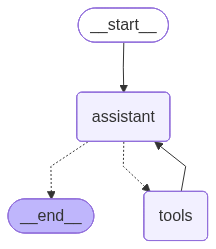

In [8]:
from IPython.display import Image, display

display(Image(alfred.get_graph(xray=True).draw_mermaid_png()))

In this notebook, I built the hybird search for Alfred to search and retrieve the guest's name, relationship, details and contact email. Also, I added session so that Alfred can remember the chat history everytime he starts a new session.